\setcounter{secnumdepth}{0}

# Problem Set 2
## Om Mehta
## FINM 37400

## 1. Hotelling's $T^2$ - small dataset

### a)

\begin{align*}
X = \begin{bmatrix}
2 & 12 \\
8 & 9 \\
6 & 9 \\
8 & 10
\end{bmatrix}, \ \mu_0 = \begin{bmatrix} 7 \\ 11 \end{bmatrix} \\
\end{align*}

In [47]:
import numpy as np

In [48]:
X = np.array([
    [2, 12],
    [8, 9],
    [6, 9],
    [9, 10]
])

xbar = np.mean(X, axis=0)
S = np.cov(X.T)
S_inv = np.linalg.inv(S)
xbar, S, S_inv

(array([ 6.25, 10.  ]),
 array([[ 9.58333333, -3.33333333],
        [-3.33333333,  2.        ]]),
 array([[0.24827586, 0.4137931 ],
        [0.4137931 , 1.18965517]]))

In [49]:
n = 4
mu_0 = np.array([7, 11]).T
meandiff = xbar - mu_0
T2 = n * (meandiff.T @ S_inv @ meandiff)
round(T2, 2)

7.8

\begin{align*}
T^2  \sim \frac{(n-1)p}{n-p}F_{p,n-p}(\alpha)
\end{align*}

\begin{align*}
T^2 \sim 3 \cdot F_{2, 2}
\end{align*}

### b)

In [50]:
C = np.array([
    [1, 1],
    [-1, 1]
])

Y = X @ C.T
y_bar = np.mean(Y, axis=0)
S_y = C @ S @ C.T
mu_0_star = C @ mu_0
diff = y_bar - mu_0_star
T2 = n * (diff.T @ np.linalg.inv(S_y) @ diff)
round(T2, 2)

7.8

### c)

\begin{align*}
T_y^2 = n(\bar{y}-\mu_y)^\top S_y^-1 (\bar{y}-\mu_y)
\end{align*}

#### With:
\begin{align*}
\bar{y} &= C \bar{x} \\ \\
\mu_y &= C \mu_0 \\ \\
S_y &= C S C^\top
\end{align*}

\begin{align*}
T_y^2=n(C(\bar{x}-\mu_0))^\top (CSC^\top)^{-1} (C(\bar{x}-\mu_0)) \\ \\
\text{Since C is invertible, } (CSC^\top)^{-1}=(C^\top)^{-1}S^{-1}C^{-1} \\ \\
T_y^2=n(C(\bar{x}-\mu_0))^\top (C^\top)^{-1}S^{-1}C^{-1} (C(\bar{x}-\mu_0))
\end{align*}

#### Let 
\begin{align*}
d=\bar{x}-\mu_0
\end{align*}

\begin{align*}
\Rightarrow T_y^2=n(Cd)^\top (C^\top)^{-1}S^{-1}C^{-1}(Cd) \\ \\
\text{Recall: } (Cd)^\top = d^\top C^\top \\ \\
\text{So: } T_y^2=n \cdot d^\top C^\top (C^\top)^{-1} S^{-1} C^{-1} Cd \\ \\
\text {Substitute: } C^\top (C^\top)^{-1} = I, \ C^{-1} C = I \\ \\
\text{So it collapses to: } T_y^2 = n(\bar{x}-\mu_0)^\top S^-1 (\bar{x}-\mu_0)
\end{align*}

## 2. Derivation in Canonical Correlation Analysis

\begin{align*}
\boldsymbol{A = \Sigma_{11}^{-1}\Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}} \\ \\
\Sigma_{11}^{-1} = \frac{1}{1-p^2}\begin{bmatrix} 1 & -p \\-p & 1 \end{bmatrix} \\ \\
\Sigma_{22}^{-1} = \frac{1}{1-q^2}\begin{bmatrix} 1 & -q \\-q & 1 \end{bmatrix} \\ \\
\Sigma_{12} = \Sigma_{21} = \begin{bmatrix} r & r \\r & r \end{bmatrix} \\ \\
\end{align*}

\begin{align*}
M = \Sigma_{11}^{-1}\Sigma_{12} = \frac{r-pr}{1-p^2}\begin{bmatrix} 1 & 1 \\ 1 & 1 \end{bmatrix} \\ \\
M \cdot \Sigma_{22}^{-1} = \frac{r-pr}{1-p^2}\begin{bmatrix} 1 & 1 \\ 1 & 1 \end{bmatrix} \begin{bmatrix} 1 & -q \\ -q & 1 \end{bmatrix} \\\\
= \frac{r-pr}{1-p^2} \cdot \frac{1-q}{1-q^2}\begin{bmatrix} 1 & 1 \\ 1 & 1 \end{bmatrix} \\ \\ 
\boldsymbol{A} = \frac{r-pr}{1-p^2} \cdot \frac{1-q}{1-q^2}\begin{bmatrix} 1 & 1 \\ 1 & 1 \end{bmatrix} \begin{bmatrix} r & r \\r & r \end{bmatrix} \\ \\ 
= \frac{r-pr}{1-p^2} \cdot \frac{1-q}{1-q^2} \cdot 2r \cdot \begin{bmatrix} 1 & 1 \\ 1 & 1 \end{bmatrix} \\ \\
= \frac{2r^2(1-p)(1-q)}{(1-p^2)(1-q^2)}\cdot \begin{bmatrix} 1 & 1 \\ 1 & 1 \end{bmatrix}
\end{align*}

\begin{align*}
\lambda_1 = 2 \cdot \frac{2r^2(1-p)(1-q)}{(1-p^2)(1-q^2)} \\ \\
\lambda_2 = 0 \\ \\
\boldsymbol{\rho_1^*} = \sqrt{\lambda_1} = \sqrt{\frac{2r^2(1-p)(1-q)}{(1-p^2)(1-q^2)}}
\end{align*}

### b)

\begin{align*}
a_1=\begin{bmatrix} 1 \\ 1 \end{bmatrix} \\ 
a_1^\top \Sigma_{11} a_1 = 1 \\ \\
\Rightarrow \begin{bmatrix} 1 & 1 \end{bmatrix} \begin{bmatrix} 1 & p \\ p & 1 \end{bmatrix} \begin{bmatrix} 1 \\ 1 \end{bmatrix} \\ \\ 
= 1 + p + p + 1 = 2(1+p) \\ \\
\Rightarrow \boldsymbol{a_1} = \frac{1}{\sqrt{2(1+p)}} \begin{bmatrix} 1 & p \\ p & 1 \end{bmatrix}
\end{align*}

\begin{align*}
b_1 = \Sigma_{22}^{-1}\Sigma_{21}a_1 \\ \\
\Sigma_{21}a_1 = \frac{2r}{\sqrt{2(1+p)}} \begin{bmatrix} 1 \\ 1 \end{bmatrix}
\end{align*}

\begin{align*}
b_1 = \frac{2r}{\sqrt{2(1+p}} \cdot \frac{1}{1-q^2} \begin{bmatrix} 1 & -q \\ -q & 1 \end{bmatrix} \begin{bmatrix} 1 \\ 1 \end{bmatrix} \\
= \frac{2r(1-q)}{(1-q^2)\sqrt{(2(1+p)}} \\ \\
\Rightarrow b_1^\top \Sigma_{22} b_1 = 1 \\ \\
\Rightarrow \boldsymbol{b_1} = \frac{1}{\sqrt{2(1+q)}} \begin{bmatrix} 1 & q \\ q & 1 \end{bmatrix}
\end{align*}

\begin{align*}
\boldsymbol{a_1} = \frac{1}{\sqrt{2(1+p)}} \begin{bmatrix} 1 & p \\ p & 1 \end{bmatrix}, \ \boldsymbol{b_1} = \frac{1}{\sqrt{2(1+q)}} \begin{bmatrix} 1 & q \\ q & 1 \end{bmatrix} \\ \\
\Rightarrow \boldsymbol{(U_1, V_1)=(a_1^\top X, b_1^\top Y)}
\end{align*}

## 3. Practice CCA, Low Dimensions

In [78]:
import pandas as pd
from sklearn.cross_decomposition import CCA
from matplotlib import pyplot as plt

In [79]:
df = pd.read_csv("stiffness.dat", sep=r"\s+", header=None)
df.columns=['x1', 'x2', 'x3', 'x4', 'd2']

In [80]:
X, Y, d2 = df[['x1', 'x2']], df[['x3', 'x4']], df['d2']

### a)

In [81]:
cca = CCA(n_components=2)
X_c, Y_c = cca.fit_transform(X, Y)

### b)

In [82]:
U, V = cca.x_weights_, cca.y_weights_
U[0], V[0]

(array([0.98710551, 0.16007097]), array([0.55489103, 0.83192304]))

### c)

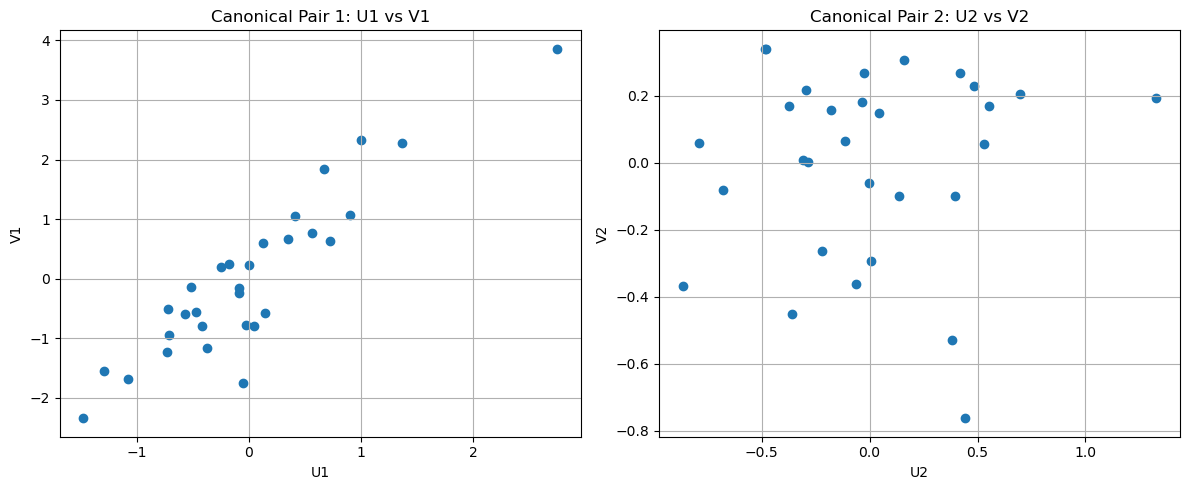

In [83]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(X_c[:, 0], Y_c[:, 0])
ax[0].set_title("Canonical Pair 1: U1 vs V1")
ax[0].set_xlabel("U1")
ax[0].set_ylabel("V1")
ax[0].grid(True)

ax[1].scatter(X_c[:, 1], Y_c[:, 1])
ax[1].set_title("Canonical Pair 2: U2 vs V2")
ax[1].set_xlabel("U2")
ax[1].set_ylabel("V2")
ax[1].grid(True)

plt.tight_layout()
plt.show()

### d)

In [84]:
rho1 = np.corrcoef(X_c[:, 0], Y_c[:, 0])[0, 1]
rho2 = np.corrcoef(X_c[:, 1], Y_c[:, 1])[0, 1]
print('Canonical correlation 1:', round(rho1, 2))
print('Canonical correlation 2:', round(rho2, 2))

Canonical correlation 1: 0.91
Canonical correlation 2: 0.07


Based on these correlations, it seems that the **first canonical pair** holds the important correlation. There is a strong linear relationship between a certain linear combination of the vibrational and static tests, suggesting that one aspect of stiffness captured by the dynamic methods is highly predictive of a similar aspect measured through static testing.

## 4. Multivariate vs. Univariate Inference

In [85]:
df = pd.read_csv("fly.dat", sep=r'\s+')
df

,Species,Ant.Length,Wing.Length
1,Af,1.38,1.64
2,Af,1.40,1.70
3,Af,1.24,1.72
4,Af,1.36,1.74
5,Af,1.38,1.82
6,Af,1.48,1.82
7,Af,1.54,1.82
8,Af,1.38,1.90
9,Af,1.56,2.08
10,Apf,1.14,1.78


In [86]:
df['Y1'] = df['Ant.Length'] + df['Wing.Length']
df['Y2'] = df['Wing.Length']
df_af = df[df['Species'] == 'Af']
df_apf = df[df['Species'] == 'Apf']
Y_af = df_af[['Y1', 'Y2']].to_numpy()
Y_apf = df_apf[['Y1', 'Y2']].to_numpy()

In [87]:
ybar_af, ybar_apf = Y_af.mean(axis=0), Y_apf.mean(axis=0)
meandiff = ybar_af-ybar_apf
S_af = np.cov(Y_af.T)
S_apf = np.cov(Y_apf.T)
n1, n2 = len(Y_af), len(Y_apf)
S_p = ((n1-1)*S_af + (n2-1)*S_apf) / n1+n2-2
T2 = ((n1*n2)/(n1+n2)) * (meandiff.T @ np.linalg.inv(S_p) @ meandiff)

In [88]:
from scipy.stats import f

In [93]:
p = 2
F = ((n1 + n2 - p - 1) / p*(n1 + n2 - 2)) * T2
df1, df2 = 2, n1 + n2 - p - 1
pvalue = 1 - f.cdf(F, df1, df2)

In [94]:
pvalue

8.260059303211165e-14

The low p-value indicates that we can reject the null hypothesis of equal mean vectors, concluding that there is a **statistically significant difference in multivariate means of $Y_1$ and $Y_2$ between the AF and APF species**.

Part ii.
Yes, we can expect the same result from $X_1$ and $X_2$ because the transformation to $Y_1$ and $Y_2$ is **linear and invertible**.

### b)

In [95]:
from scipy.stats import ttest_ind

t_stat_y1, p_y1 = ttest_ind(df_af['Y1'], df_apf['Y1'], equal_var=True)
t_stat_y2, p_y2 = ttest_ind(df_af['Y2'], df_apf['Y2'], equal_var=True)
print("p-value for Y1:", round(p_y1, 4))
print("p-value for Y2:", round(p_y2, 4))

p-value for Y1: 0.5202
p-value for Y2: 0.0663


Though neither of the *univariate* tests for $Y_1$ and $Y_2$ yielded significance at the $\alpha=0.01, 0.05$ levels, Hotelling's $T^2$ test from part a) detected a statistically significant difference in the joint distribution of $Y_1$ and $Y_2$. This indicates that **multivariate tests reveal more structure that univariate tests miss, especially when variables are correlated.**

### c)

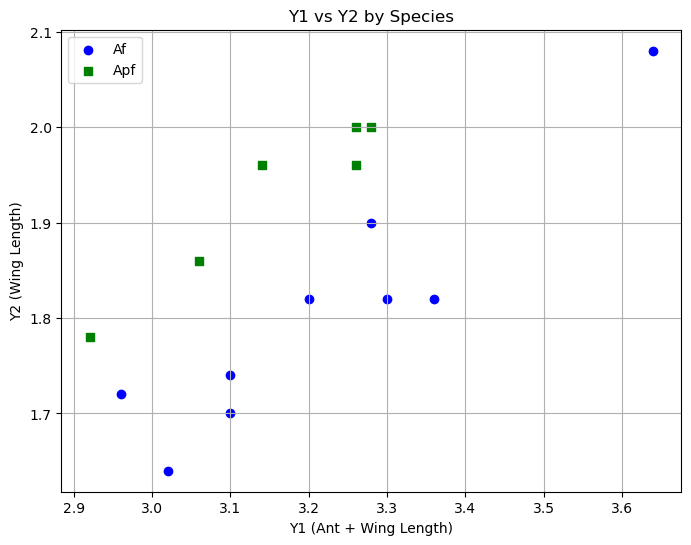

In [96]:
plt.figure(figsize=(8, 6))

# Species Af
plt.scatter(df_af['Y1'], df_af['Y2'], color='blue', marker='o', label='Af')

# Species Apf
plt.scatter(df_apf['Y1'], df_apf['Y2'], color='green', marker='s', label='Apf')

# Labels and title
plt.xlabel("Y1 (Ant + Wing Length)")
plt.ylabel("Y2 (Wing Length)")
plt.title("Y1 vs Y2 by Species")
plt.grid(True)
plt.legend()
plt.show()

### d)

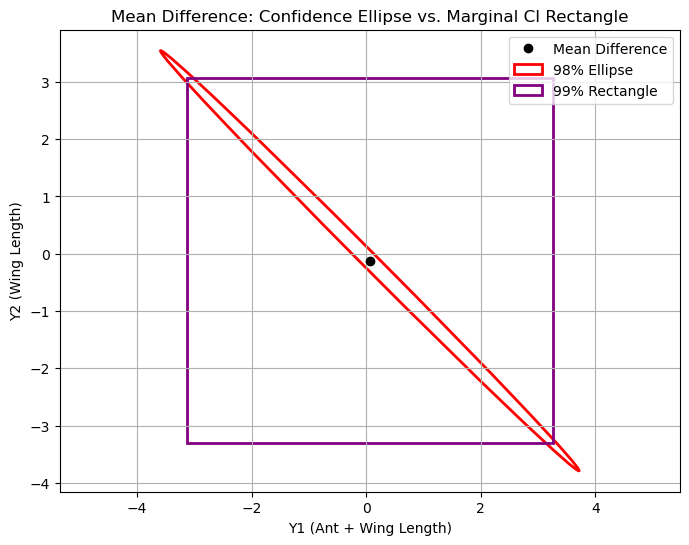

In [104]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(mean_diff[0], mean_diff[1], 'ko', label='Mean Difference')

ellipse = Ellipse(xy=mean_diff, width=width, height=height,
                  angle=angle, edgecolor='red', fc='None', lw=2, label='98% Ellipse')
ax.add_patch(ellipse)

rectangle = Rectangle(lower_left, rect_width, rect_height,
                      edgecolor='purple', fc='None', lw=2, label='99% Rectangle')
ax.add_patch(rectangle)

ax.set_xlabel("Y1 (Ant + Wing Length)")
ax.set_ylabel("Y2 (Wing Length)")
ax.set_title("Mean Difference: Confidence Ellipse vs. Marginal CI Rectangle")
ax.grid(True)
ax.legend()
plt.axis('equal')
plt.show()

**iii.** The rectangle in part ii.) is constructed from two separate $99\%$ marginal confidence intervals--one for the mean difference in $Y_1$, and one for the mean difference in $Y_2$. Using the Bonferroni correction for two comparisons, we adjust the per-variable confidence level to ensure that the overall (joint) confidence level is at least $98\%$.

**iv.** The zero vector is inside both the ellipse and the rectange, implying that at both levels we fail to reject the null hypothesis that the true species mean difference is zero. 

## 5. Vector-matrix derivations for multivatiate data and random variables

### a)

\begin{align*}
\text{Let: } X_c=X-\boldsymbol{1}_n\bar{x}^\top \\ \\
\bar{x} = \frac{1}{n}\boldsymbol{1}_n^\top X \Rightarrow X_c = X-\frac{1}{n}\boldsymbol{1}_n\boldsymbol{1}_n^\top X \\ \\
X_c = HX \ \text{ where } \ H = I_n-\frac{1}{n}\boldsymbol{1}_n\boldsymbol{1}_n^\top \\ \\
S = \frac{1}{n - 1} X_c' X_c  = \frac{1}{n - 1} (H X)' (H X) 
= \frac{1}{n - 1} X' H' H X \\ \\ 
H' = H \quad \text{and} \quad H^2 = H 
\quad \Rightarrow \quad 
S = \frac{1}{n - 1} X' H X
\end{align*}

### b)

\begin{align*}
\text{Cov}[\boldsymbol{W}] 
&= \mathbb{E}\left[(\boldsymbol{W} - \mathbb{E}[\boldsymbol{W}])(\boldsymbol{W} - \mathbb{E}[\boldsymbol{W}])^\top\right] \\
\\
\text{Substitute } \boldsymbol{W} = \boldsymbol{A}\boldsymbol{Y} + \boldsymbol{c}, \text{ so } \mathbb{E}[\boldsymbol{W}] = \boldsymbol{A} \mathbb{E}[\boldsymbol{Y}] + \boldsymbol{c} \\
\\
\Rightarrow \text{Cov}[\boldsymbol{W}] 
&= \mathbb{E}\left[(\boldsymbol{A}(\boldsymbol{Y} - \mathbb{E}[\boldsymbol{Y}]))(\boldsymbol{A}(\boldsymbol{Y} - \mathbb{E}[\boldsymbol{Y}]))^\top\right] \\
\\
&= \mathbb{E}\left[\boldsymbol{A}(\boldsymbol{Y} - \mathbb{E}[\boldsymbol{Y}])(\boldsymbol{Y} - \mathbb{E}[\boldsymbol{Y}])^\top \boldsymbol{A}^\top\right] \\
\\
&= \boldsymbol{A} \, \mathbb{E}\left[(\boldsymbol{Y} - \mathbb{E}[\boldsymbol{Y}])(\boldsymbol{Y} - \mathbb{E}[\boldsymbol{Y}])^\top\right] \boldsymbol{A}^\top \\
\\
&= \boldsymbol{A} \, \text{Cov}[\boldsymbol{Y}] \, \boldsymbol{A}^\top
\end{align*}

### c)

\begin{align*}
\text{Cov}(\mathbf{a}^\top \mathbf{Y}, \mathbf{b}^\top \mathbf{W}) 
&= \mathbb{E}\left[(\mathbf{a}^\top \mathbf{Y} - \mathbb{E}[\mathbf{a}^\top \mathbf{Y}])(\mathbf{b}^\top \mathbf{W} - \mathbb{E}[\mathbf{b}^\top \mathbf{W}])\right] \\
\\
&= \mathbb{E}\left[\mathbf{a}^\top (\mathbf{Y} - \mathbb{E}[\mathbf{Y}]) \cdot (\mathbf{W} - \mathbb{E}[\mathbf{W}])^\top \mathbf{b} \right] \\
\\
&= \mathbf{a}^\top \, \mathbb{E}\left[(\mathbf{Y} - \mathbb{E}[\mathbf{Y}])(\mathbf{W} - \mathbb{E}[\mathbf{W}])^\top\right] \, \mathbf{b} \\
\\
&= \mathbf{a}^\top \, \text{Cov}(\mathbf{Y}, \mathbf{W}) \, \mathbf{b}
\end{align*}